# Quantum Repeater Network — Metrics Study

All figures studying distillation, multiplexing, radius, P\_BSM, and multiphoton error.  
All runs use `multiphoton=False` except **Figure 7** (multiphoton comparison).

**Fairness note:** All comparisons that sweep a parameter (radius, P\_BSM, distillation level,  
multiphoton) build a **single shared graph topology per radius** and reuse it across all  
configurations being compared — following the approach in `analysis_plots_dist`.  
This ensures differences reflect physics, not topology noise.

| # | Figure | X-axis | Notes |
|---|--------|--------|-------|
| 1 | Master: all mux × before/after | Distillation level | Fixed topology per radius |
| 2 | Distillation level study | Distillation level (lines = radii) | Shared graph per radius |
| 3 | Before vs After swap | Network radius | Same graph both timing modes |
| 4 | Distillation vs Accumulated mux | Network radius | Same graph all configs |
| 5 | Distillation vs Single-burst mux | Network radius | Same graph all configs |
| 6 | P\_BSM sweep — all configurations | P\_BSM | Fixed graph, only P\_BSM varies |
| 7 | Multiphoton error ON vs OFF | Network radius | Same graph both modes |
| 8 | Dijkstra diagnostics: hops & distance vs P\_BSM | P\_BSM (panels = radii) | Same graph |
| 9 | After-swap equivalents of Figs 1–5 | (same as before-swap counterparts) | Before/after on same topology |
| 10 | Bonus exploratory plots | Various | 8 plot types with justification |

> **Multiphoton paradox** (Fig 7): avg entanglement generation is *higher* when multiphoton  
> is ON despite reachability being lower. This is a **survivorship bias** effect — multiphoton  
> errors increase QBER, causing more long/multi-hop paths to fall below the SKR > 0 threshold.  
> The remaining reachable pairs are the nearby ones with short, low-loss paths and intrinsically  
> higher raw generation rates. The reported average is the mean over reachable pairs only, so  
> it is biased upward by the removal of the slowest paths.

> **Distillation level paradox** (why higher level ≠ better results): Each additional  
> distillation round doubles the number of entangled pairs consumed and approximately doubles  
> the waiting time (T). During that waiting time, coherence decays exponentially (∝ exp(−T/T_coh)).  
> At typical operating distances and T_coh = 50 ms, the coherence penalty exceeds the fidelity  
> gain from BBPSSW purification, so higher distillation levels net *worse* SKR and  
> reachability. This is expected behaviour — distillation only helps when p_pair is large  
> enough that the round-trip waiting time stays well within T_coh.

> Raise `N_NODES` and `N_TRIALS` for smoother curves at the cost of runtime.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sequential_repeaters_dist import (
    RepeaterParams, QuantumRepeaterNetwork,
    build_radius_graph, build_density_graph, density_to_scale
)


## Global settings

In [2]:
# ── Physical parameters ──────────────────────────────────────────────────────
def make_params(P_BSM=0.5):
    p            = RepeaterParams()
    p.p_det      = 0.95
    p.alpha      = 0.18
    p.q_0        = 0.01
    p.nu         = 1e9
    p.R_dark     = 100
    p.delta_det  = 100e-12
    p.p_pair     = 0.05
    p.eta_c      = 0.8
    p.P_BSM      = P_BSM
    p.T_coh      = 0.05
    return p

# ── Sweep knobs ──────────────────────────────────────────────────────────────
N_NODES  = 100
N_TRIALS = 5
BETA     = 2.6261
MU       = 0.0233
M_MUX    = 1e4

RADII       = np.array([10, 50, 100, 175, 250, 325, 400])  # km
DIST_LEVELS = [1, 2, 3]
MUX_MODES   = [None, 'single_burst', 'accumulated']
DIST_TIMES  = ['before_swap', 'after_swap']

RADIUS_LARGE    = 120    # km
P_BSM_VALUES    = np.linspace(0.05, 0.95, 10)

RADII_DIJKSTRA  = [10, 40, 325]
RADII_KDE       = [10, 40, 160]   # km
SOURCE_NODE     = 0
TARGET_NODE     = N_NODES - 1

sns.set_theme(style='darkgrid', font_scale=1.05)

METRIC_KEYS   = ['avg_rate', 'avg_skr', 'reachability']
METRIC_LABELS = {
    'avg_rate':    'Avg entanglement rate  [pairs/s]',
    'avg_skr':     'Avg SKR  [bits/s]  (negatives → 0)',
    'reachability':'Reachability  [%]',
}

print('Settings loaded.')


Settings loaded.


## Core helpers

### Fairness: shared-topology design

Following `analysis_plots_dist`, all sweep functions build one graph per radius  
**once** and pass it into every configuration under comparison.  `run_metrics_on_graph`  
accepts a pre-built `(A, dist, coords)` triple; `build_shared_graphs` pre-builds  
a dict keyed by radius.  The old `run_metrics` that builds a new graph internally  
is retained for backward compatibility but is no longer used by Figures 1–8.


In [3]:
import os
os.makedirs('plots', exist_ok=True)

# ── Shared-topology helpers ───────────────────────────────────────────────────

def build_shared_graphs(radii, n_nodes=N_NODES, n_trials=N_TRIALS):
    """
    Build N_TRIALS graph realisations for each radius.
    Returns dict: radius_km -> list of (A, dist, coords) tuples.
    Graphs are built ONCE and reused across all configurations.
    """
    graphs = {}
    for r in radii:
        print(f'  Building {n_trials} graph(s) for r={r} km …')
        graphs[r] = []
        for _ in range(n_trials):
            A, dist, coords, _ = build_radius_graph(n_nodes, r, BETA, MU)
            graphs[r].append((A, dist, coords))
    return graphs


def run_metrics_on_graph(A, dist, coords, radius_km,
                         distillation=False, multiplexing_type=None,
                         distillation_level=1, distillation_time='before_swap',
                         multiphoton=False, P_BSM=0.5):
    """Compute network_metrics on a pre-built graph."""
    net = QuantumRepeaterNetwork(
        make_params(P_BSM), A, dist, coords,
        architecture='node', scale=float(radius_km),
        multiphoton=multiphoton,
        distillation=distillation,
        multiplexing_type=multiplexing_type,
        M=M_MUX,
        distillation_level=distillation_level,
        distillation_time=distillation_time,
    )
    m = net.network_metrics(verbose=False)
    out = {}
    for k in METRIC_KEYS:
        if k == 'reachability':
            out[k] = m[k] * 100
        elif k == 'avg_skr':
            # avg_skr may not exist in older network_metrics — fall back gracefully
            out[k] = m.get('avg_skr', 0.0)
        else:
            out[k] = m[k]
    return out


def radius_sweep_shared(shared_graphs, radii, tag='', **kw):
    """
    Run over a list of radii using shared graph topologies.
    shared_graphs: dict radius -> list of (A, dist, coords).
    Returns {metric: [mean_value_per_radius]}.
    """
    data = {m: [] for m in METRIC_KEYS}
    for r in radii:
        if tag: print(f'  [{tag}]  r={r} km …')
        trials = {m: [] for m in METRIC_KEYS}
        for A, dist, coords in shared_graphs[r]:
            res = run_metrics_on_graph(A, dist, coords, r, **kw)
            for m in METRIC_KEYS:
                trials[m].append(res[m])
        for m in METRIC_KEYS:
            data[m].append(np.mean(trials[m]))
    return data


def pbsm_sweep_shared(shared_graphs, p_vals, radius_km, tag='', **kw):
    """
    Sweep P_BSM values on a single pre-built graph ensemble at radius_km.
    Returns {metric: [mean_value_per_P_BSM]}.
    """
    data = {m: [] for m in METRIC_KEYS}
    for pb in p_vals:
        if tag: print(f'  [{tag}]  P_BSM={pb:.2f} …')
        trials = {m: [] for m in METRIC_KEYS}
        for A, dist, coords in shared_graphs[radius_km]:
            res = run_metrics_on_graph(A, dist, coords, radius_km, P_BSM=pb, **kw)
            for m in METRIC_KEYS:
                trials[m].append(res[m])
        for m in METRIC_KEYS:
            data[m].append(np.mean(trials[m]))
    return data


# ── Legacy single-graph helper (kept for compatibility) ───────────────────────

def run_metrics(radius_km, distillation=False, multiplexing_type=None,
                distillation_level=1, distillation_time='before_swap',
                multiphoton=False, P_BSM=0.5, n_trials=N_TRIALS):
    """Average network_metrics over n_trials new graph realisations (legacy)."""
    acc = {m: [] for m in METRIC_KEYS}
    for _ in range(n_trials):
        A, dist, coords, _ = build_radius_graph(N_NODES, radius_km, BETA, MU)
        res = run_metrics_on_graph(A, dist, coords, radius_km,
                                   distillation=distillation,
                                   multiplexing_type=multiplexing_type,
                                   distillation_level=distillation_level,
                                   distillation_time=distillation_time,
                                   multiphoton=multiphoton, P_BSM=P_BSM)
        for m in METRIC_KEYS:
            acc[m].append(res[m])
    return {k: np.mean(v) for k, v in acc.items()}


# ── Plot helpers ──────────────────────────────────────────────────────────────

def make_fig(title='', height=4.5):
    fig, axes = plt.subplots(1, 3, figsize=(22, height))
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    return fig, axes


def finish_axes(axes, xlabel, xscale='log'):
    for ax, key in zip(axes, METRIC_KEYS):
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(METRIC_LABELS[key], fontsize=11)
        ax.set_xscale(xscale)
        if key == 'reachability':
            pass  # linear scale
        elif key == 'avg_skr':
            # SKR can be 0 for many pairs — symlog lets us see the scale
            ax.set_yscale('log')
        else:
            ax.set_yscale('log')
        ax.legend(fontsize=8, framealpha=0.75)


def plot_line(axes, x, data, label, color, ls='-', marker='o', lw=1.8, ms=6):
    for ax, key in zip(axes, METRIC_KEYS):
        ax.plot(x, data[key], marker=marker, linestyle=ls,
                color=color, label=label, linewidth=lw, markersize=ms)


print('Helpers ready.')


Helpers ready.


## Pre-build shared graph topologies

Run this cell **once**.  All figure cells below reuse these topologies so that  
comparisons across configurations are fair (same nodes, same edges).


In [4]:
# Build shared graphs for all radius values used in the notebook
ALL_RADII = sorted(set(list(RADII) + [RADIUS_LARGE] + RADII_DIJKSTRA + RADII_KDE))
print(f'Pre-building graphs for radii: {ALL_RADII} km')
SHARED_GRAPHS = build_shared_graphs(ALL_RADII)

# Also build a finer set for Figs 2 and KDE
RADII_2 = [5, 20, 80, 160]
print(f'Pre-building graphs for Fig 2 radii: {RADII_2} km')
SHARED_GRAPHS_2 = build_shared_graphs(RADII_2)
RADIUS_MASTER = 100

print('All shared graphs built.')


Pre-building graphs for radii: [np.int64(10), 40, np.int64(50), np.int64(100), 120, 160, np.int64(175), np.int64(250), np.int64(325), np.int64(400)] km
  Building 5 graph(s) for r=10 km …
  Building 5 graph(s) for r=40 km …
  Building 5 graph(s) for r=50 km …
  Building 5 graph(s) for r=100 km …
  Building 5 graph(s) for r=120 km …
  Building 5 graph(s) for r=160 km …
  Building 5 graph(s) for r=175 km …
  Building 5 graph(s) for r=250 km …
  Building 5 graph(s) for r=325 km …
  Building 5 graph(s) for r=400 km …
Pre-building graphs for Fig 2 radii: [5, 20, 80, 160] km
  Building 5 graph(s) for r=5 km …
  Building 5 graph(s) for r=20 km …
  Building 5 graph(s) for r=80 km …
  Building 5 graph(s) for r=160 km …
All shared graphs built.


---
## Figure 1 — Master graph
Distillation ON. 3 mux modes × 2 distillation times = 6 lines.  
X-axis: distillation level. Fixed radius = 100 km.  
**Fairness:** same graph topology used for all 6 lines.


  no-mux | before_swap | level=1 …
  no-mux | before_swap | level=2 …
  no-mux | before_swap | level=3 …
  no-mux | after_swap | level=1 …
  no-mux | after_swap | level=2 …
  no-mux | after_swap | level=3 …
  single-burst | before_swap | level=1 …
  single-burst | before_swap | level=2 …
  single-burst | before_swap | level=3 …
  single-burst | after_swap | level=1 …
  single-burst | after_swap | level=2 …
  single-burst | after_swap | level=3 …
  accumulated | before_swap | level=1 …
  accumulated | before_swap | level=2 …
  accumulated | before_swap | level=3 …
  accumulated | after_swap | level=1 …
  accumulated | after_swap | level=2 …
  accumulated | after_swap | level=3 …


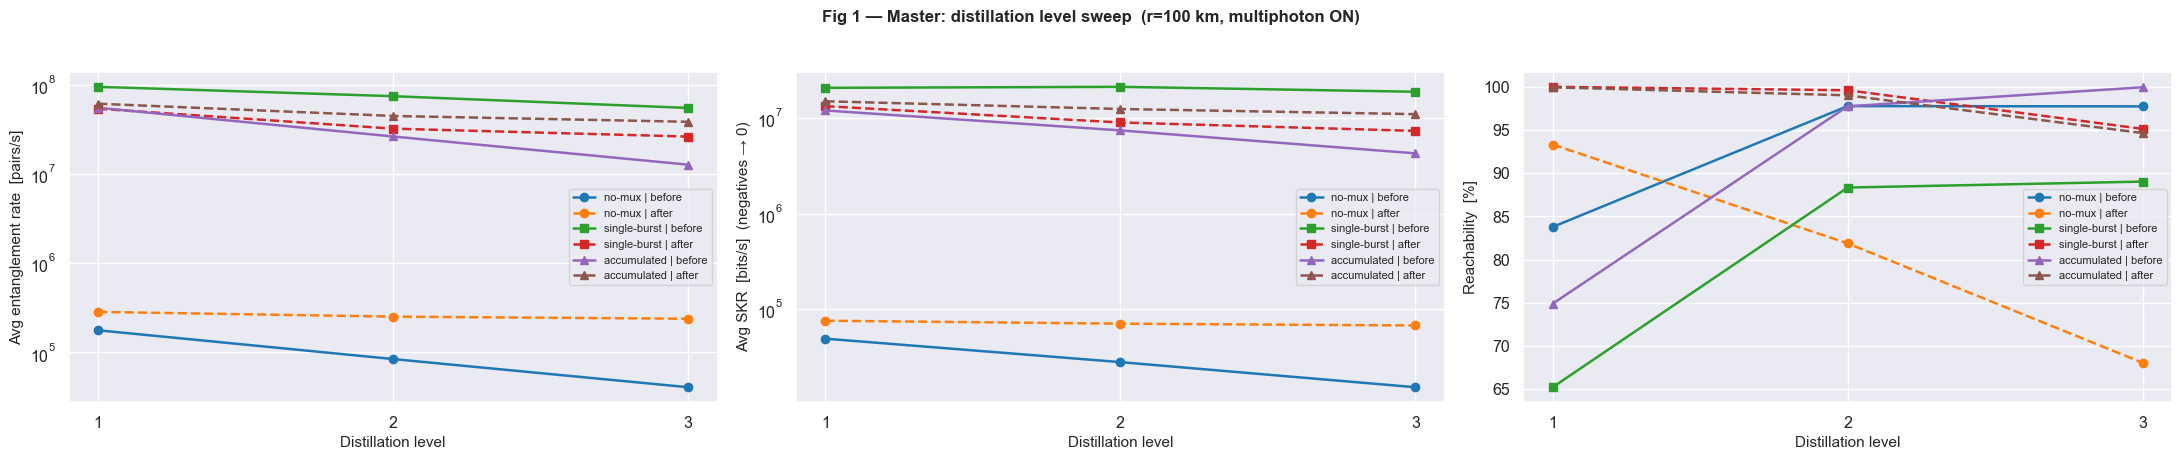

Figure 1 done.


In [5]:
LEVELS = [1, 2, 3]

pal1       = sns.color_palette('tab10', 6)
mux_lbl    = {None: 'no-mux', 'single_burst': 'single-burst', 'accumulated': 'accumulated'}
mux_marker = {None: 'o', 'single_burst': 's', 'accumulated': '^'}
time_ls    = {'before_swap': '-', 'after_swap': '--'}

fig1, axes1 = make_fig(f'Fig 1 — Master: distillation level sweep  (r={RADIUS_MASTER} km, multiphoton ON)')

ci = 0
for mux in MUX_MODES:
    for dtime in DIST_TIMES:
        data = {m: [] for m in METRIC_KEYS}
        for lv in LEVELS:
            print(f'  {mux_lbl[mux]} | {dtime} | level={lv} …')
            # Use shared graph for radius=RADIUS_MASTER
            trials = {m: [] for m in METRIC_KEYS}
            for A, dist, coords in SHARED_GRAPHS[RADIUS_MASTER]:
                res = run_metrics_on_graph(
                    A, dist, coords, RADIUS_MASTER,
                    distillation=True, multiplexing_type=mux,
                    distillation_level=lv, distillation_time=dtime, multiphoton=True
                )
                for m in METRIC_KEYS:
                    trials[m].append(res[m])
            for m in METRIC_KEYS:
                data[m].append(np.mean(trials[m]))
        plot_line(axes1, LEVELS, data,
                  label=f"{mux_lbl[mux]} | {dtime.replace('_swap', '')}",
                  color=pal1[ci], ls=time_ls[dtime], marker=mux_marker[mux])
        ci += 1

finish_axes(axes1, xlabel='Distillation level', xscale='linear')
for ax in axes1: ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('plots/fig1_master_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 done.')


---
## Figure 2 — Distillation level study
Distillation ON, mux=None, before swap. Lines = radii. X-axis = distillation level.  
**Fairness:** same topology per radius across all distillation levels.


  r=5 km | level=1 …
  r=5 km | level=2 …
  r=5 km | level=3 …
  r=20 km | level=1 …
  r=20 km | level=2 …
  r=20 km | level=3 …
  r=80 km | level=1 …
  r=80 km | level=2 …
  r=80 km | level=3 …
  r=160 km | level=1 …
  r=160 km | level=2 …
  r=160 km | level=3 …


KeyboardInterrupt: 

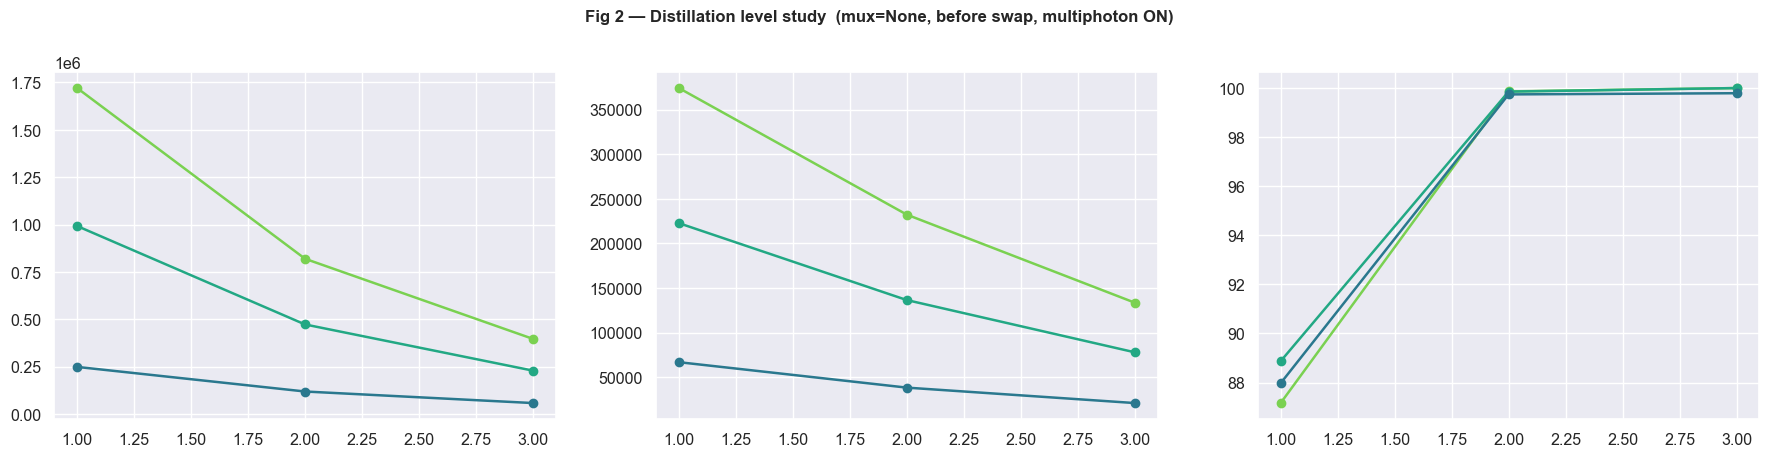

In [6]:
pal2 = sns.color_palette('viridis_r', len(RADII_2))

fig2, axes2 = make_fig('Fig 2 — Distillation level study  (mux=None, before swap, multiphoton ON)')

for ci, r in enumerate(RADII_2):
    data = {m: [] for m in METRIC_KEYS}
    for lv in LEVELS:
        print(f'  r={r} km | level={lv} …')
        trials = {m: [] for m in METRIC_KEYS}
        for A, dist, coords in SHARED_GRAPHS_2[r]:
            res = run_metrics_on_graph(A, dist, coords, r,
                                       distillation=True, multiplexing_type=None,
                                       distillation_level=lv,
                                       distillation_time='before_swap', multiphoton=True)
            for m in METRIC_KEYS:
                trials[m].append(res[m])
        for m in METRIC_KEYS:
            data[m].append(np.mean(trials[m]))
    plot_line(axes2, LEVELS, data, label=f'r = {r} km', color=pal2[ci])

finish_axes(axes2, xlabel='Distillation level', xscale='linear')
for ax in axes2: ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('plots/fig2_distillation_level_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 done.')


---
## Figure 3 — Before vs After swap
Distillation ON, mux=None, level=1. X-axis = radius.  
**Fairness:** both timing modes run on the **same** graph at each radius.


In [ ]:
pal3 = sns.color_palette('Set2', 2)
fig3, axes3 = make_fig('Fig 3 — Before vs After swap  (mux=None, level=1, multiphoton ON)')

for ci, dtime in enumerate(DIST_TIMES):
    data = radius_sweep_shared(
        SHARED_GRAPHS, RADII,
        distillation=True, multiplexing_type=None,
        distillation_level=1, distillation_time=dtime, multiphoton=True,
        tag=dtime.replace('_', ' ')
    )
    plot_line(axes3, RADII, data, label=dtime.replace('_', ' '), color=pal3[ci])

finish_axes(axes3, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('plots/fig3_before_after_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 done.')


---
## Figure 4 — Distillation vs Accumulated multiplexing
Baseline + distillation levels 1–3 (solid) + accumulated mux no-distillation (dashed).  
X-axis = radius. **Fairness:** same graph per radius for all lines.


  [baseline]  r=10 km …
  [baseline]  r=50 km …
  [baseline]  r=100 km …
  [baseline]  r=175 km …
  [baseline]  r=250 km …
  [baseline]  r=325 km …
  [baseline]  r=400 km …
  [dist lv1]  r=10 km …
  [dist lv1]  r=50 km …
  [dist lv1]  r=100 km …
  [dist lv1]  r=175 km …
  [dist lv1]  r=250 km …
  [dist lv1]  r=325 km …
  [dist lv1]  r=400 km …
  [dist lv2]  r=10 km …
  [dist lv2]  r=50 km …
  [dist lv2]  r=100 km …
  [dist lv2]  r=175 km …
  [dist lv2]  r=250 km …
  [dist lv2]  r=325 km …
  [dist lv2]  r=400 km …
  [dist lv3]  r=10 km …
  [dist lv3]  r=50 km …
  [dist lv3]  r=100 km …
  [dist lv3]  r=175 km …
  [dist lv3]  r=250 km …
  [dist lv3]  r=325 km …
  [dist lv3]  r=400 km …
  [accumulated mux]  r=10 km …
  [accumulated mux]  r=50 km …
  [accumulated mux]  r=100 km …
  [accumulated mux]  r=175 km …
  [accumulated mux]  r=250 km …
  [accumulated mux]  r=325 km …
  [accumulated mux]  r=400 km …
  [accumulated mux]  r=10 km …
  [accumulated mux]  r=50 km …
  [accumulated mux]  r=1

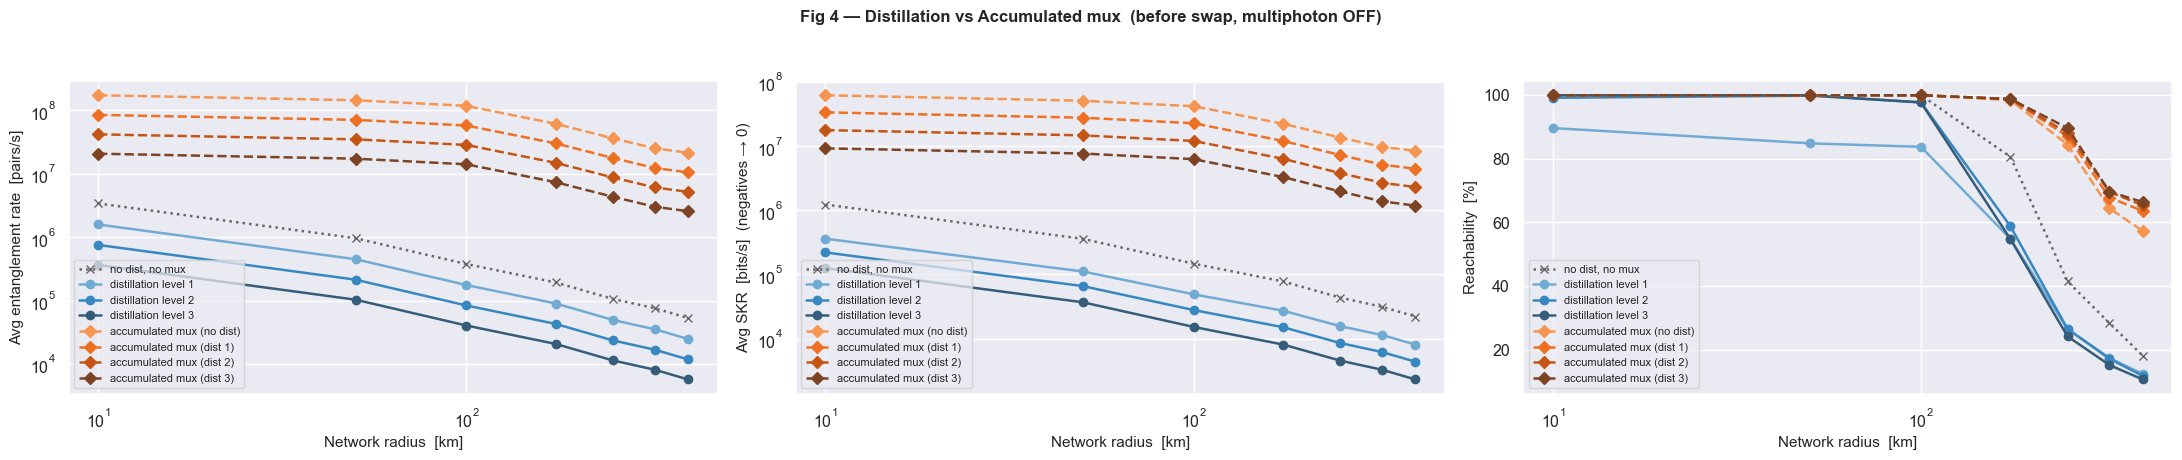

Figure 4 done.


In [16]:
pal4_grey = sns.color_palette('Greys_d', 1)
pal4_blue = sns.color_palette('Blues_d', 3)
pal4_org  = sns.color_palette('Oranges_d', 4)

fig4, axes4 = make_fig('Fig 4 — Distillation vs Accumulated mux  (before swap, multiphoton OFF)')

plot_line(axes4, RADII,
          radius_sweep_shared(SHARED_GRAPHS, RADII, multiphoton=False,
                              distillation=False, tag='baseline'),
          'no dist, no mux', pal4_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes4, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type=None,
                                  distillation_level=lv,
                                  multiphoton=True,
                                  distillation_time='before_swap',
                                  tag=f'dist lv{lv}'),
              f'distillation level {lv}', pal4_blue[li])

plot_line(axes4, RADII,
          radius_sweep_shared(SHARED_GRAPHS, RADII,
                              distillation=False, multiplexing_type='accumulated', multiphoton=False,
                              tag='accumulated mux'),
          'accumulated mux (no dist)', pal4_org[0], ls='--', marker='D')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes4, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type='accumulated', multiphoton=False, distillation_level=lv,
                                  tag='accumulated mux'),
              f'accumulated mux (dist {lv})', pal4_org[li+1], ls='--', marker='D')

finish_axes(axes4, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('plots/fig4_dist_vs_accumulated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 done.')


---
## Figure 5 — Distillation vs Single-burst multiplexing
Baseline + distillation-only (solid blue) + single-burst+distillation (dashed green).  
X-axis = radius. **Fairness:** same graph per radius for all lines.


  [baseline]  r=10 km …
  [baseline]  r=50 km …
  [baseline]  r=100 km …
  [baseline]  r=175 km …
  [baseline]  r=250 km …
  [baseline]  r=325 km …
  [baseline]  r=400 km …
  [dist-only lv1]  r=10 km …
  [dist-only lv1]  r=50 km …
  [dist-only lv1]  r=100 km …
  [dist-only lv1]  r=175 km …
  [dist-only lv1]  r=250 km …
  [dist-only lv1]  r=325 km …
  [dist-only lv1]  r=400 km …
  [dist-only lv2]  r=10 km …
  [dist-only lv2]  r=50 km …
  [dist-only lv2]  r=100 km …
  [dist-only lv2]  r=175 km …
  [dist-only lv2]  r=250 km …
  [dist-only lv2]  r=325 km …
  [dist-only lv2]  r=400 km …
  [dist-only lv3]  r=10 km …
  [dist-only lv3]  r=50 km …
  [dist-only lv3]  r=100 km …
  [dist-only lv3]  r=175 km …
  [dist-only lv3]  r=250 km …
  [dist-only lv3]  r=325 km …
  [dist-only lv3]  r=400 km …
  [single-burst lv1]  r=10 km …
  [single-burst lv1]  r=50 km …
  [single-burst lv1]  r=100 km …
  [single-burst lv1]  r=175 km …
  [single-burst lv1]  r=250 km …
  [single-burst lv1]  r=325 km …
  [sing

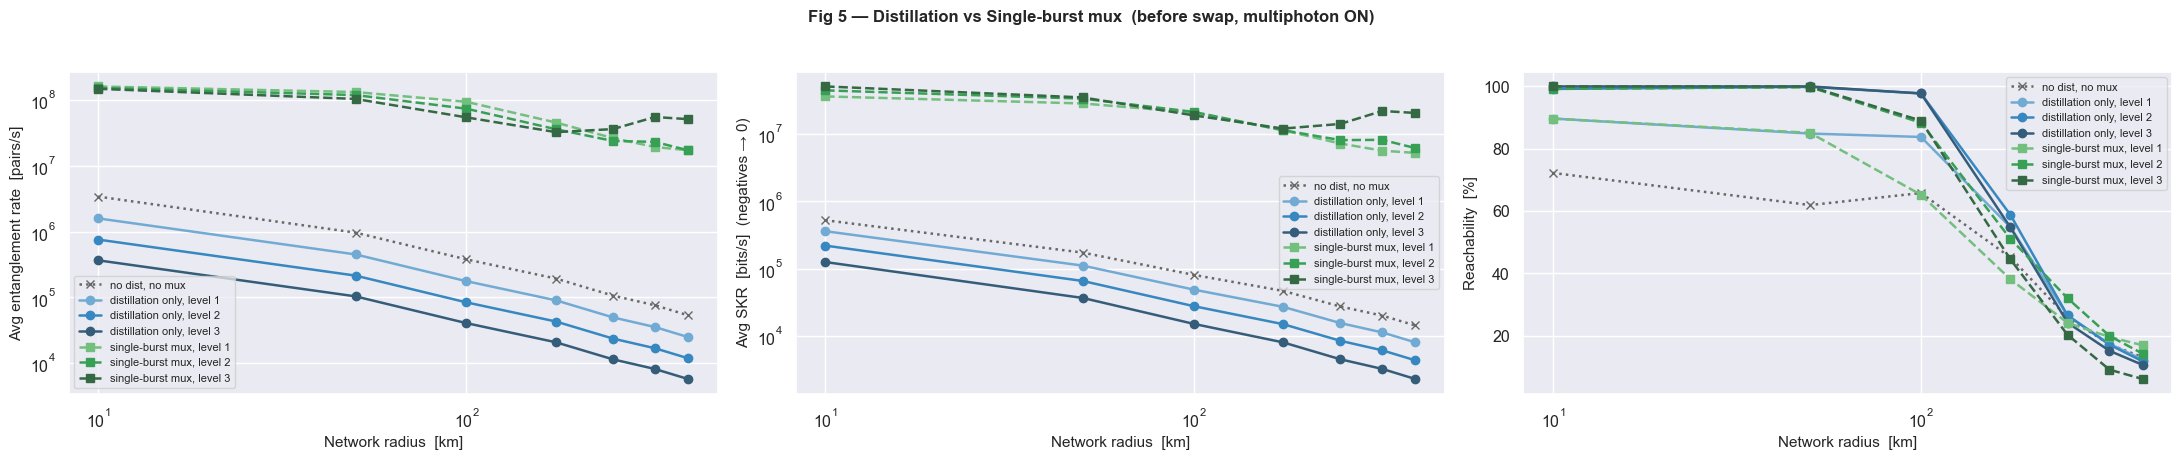

Figure 5 done.


In [23]:
pal5_grey  = sns.color_palette('Greys_d',  1)
pal5_blue  = sns.color_palette('Blues_d',  3)
pal5_green = sns.color_palette('Greens_d', 3)

fig5, axes5 = make_fig('Fig 5 — Distillation vs Single-burst mux  (before swap, multiphoton ON)')

plot_line(axes5, RADII,
          radius_sweep_shared(SHARED_GRAPHS, RADII, multiphoton=True,
                              distillation=False, tag='baseline'),
          'no dist, no mux', pal5_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes5, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type=None,
                                  distillation_level=lv,
                                  distillation_time='before_swap',
                                  multiphoton=True,
                                  tag=f'dist-only lv{lv}'),
              f'distillation only, level {lv}', pal5_blue[li], ls='-', marker='o')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes5, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type='single_burst',
                                  distillation_level=lv,
                                  multiphoton=True,
                                  distillation_time='before_swap',
                                  tag=f'single-burst lv{lv}'),
              f'single-burst mux, level {lv}', pal5_green[li], ls='--', marker='s')

finish_axes(axes5, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('plots/fig5_dist_vs_singleburst_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 done.')


---
## Figure 6 — P\_BSM sweep
Fixed radius = 120 km. All configurations.  
**Fairness:** the graph ensemble at r=120 km is held fixed; only P\_BSM varies.


  [baseline]  P_BSM=0.05 …
  [baseline]  P_BSM=0.15 …
  [baseline]  P_BSM=0.25 …
  [baseline]  P_BSM=0.35 …
  [baseline]  P_BSM=0.45 …
  [baseline]  P_BSM=0.55 …
  [baseline]  P_BSM=0.65 …
  [baseline]  P_BSM=0.75 …
  [baseline]  P_BSM=0.85 …
  [baseline]  P_BSM=0.95 …
  [dist lv1]  P_BSM=0.05 …
  [dist lv1]  P_BSM=0.15 …
  [dist lv1]  P_BSM=0.25 …
  [dist lv1]  P_BSM=0.35 …
  [dist lv1]  P_BSM=0.45 …
  [dist lv1]  P_BSM=0.55 …
  [dist lv1]  P_BSM=0.65 …
  [dist lv1]  P_BSM=0.75 …
  [dist lv1]  P_BSM=0.85 …
  [dist lv1]  P_BSM=0.95 …
  [dist lv2]  P_BSM=0.05 …
  [dist lv2]  P_BSM=0.15 …
  [dist lv2]  P_BSM=0.25 …
  [dist lv2]  P_BSM=0.35 …
  [dist lv2]  P_BSM=0.45 …
  [dist lv2]  P_BSM=0.55 …
  [dist lv2]  P_BSM=0.65 …
  [dist lv2]  P_BSM=0.75 …
  [dist lv2]  P_BSM=0.85 …
  [dist lv2]  P_BSM=0.95 …
  [dist lv3]  P_BSM=0.05 …
  [dist lv3]  P_BSM=0.15 …
  [dist lv3]  P_BSM=0.25 …
  [dist lv3]  P_BSM=0.35 …
  [dist lv3]  P_BSM=0.45 …
  [dist lv3]  P_BSM=0.55 …
  [dist lv3]  P_BSM=0.65 …
 

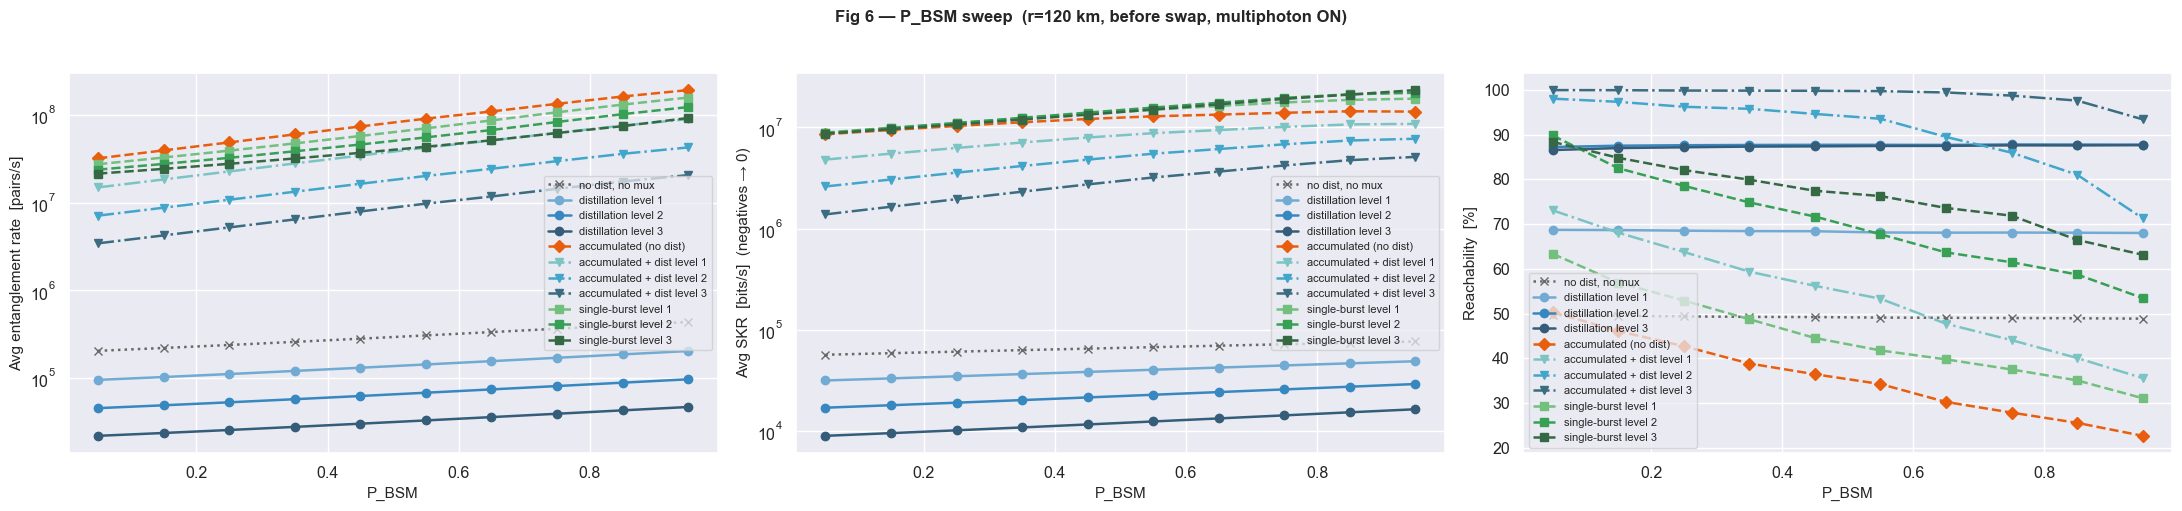

Figure 6 done.


In [17]:
pal6_grey  = sns.color_palette('Greys_d',   1)
pal6_blue  = sns.color_palette('Blues_d',   3)
pal6_org   = sns.color_palette('Oranges_d', 1)
pal6_teal  = sns.color_palette('GnBu_d',    3)
pal6_green = sns.color_palette('Greens_d',  3)

fig6, axes6 = make_fig(f'Fig 6 — P_BSM sweep  (r={RADIUS_LARGE} km, before swap, multiphoton ON)',
                       height=5)

plot_line(axes6, P_BSM_VALUES,
          pbsm_sweep_shared(SHARED_GRAPHS, P_BSM_VALUES, RADIUS_LARGE, multiphoton=True,
                            distillation=False, tag='baseline'),
          'no dist, no mux', pal6_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes6, P_BSM_VALUES,
              pbsm_sweep_shared(SHARED_GRAPHS, P_BSM_VALUES, RADIUS_LARGE,
                                distillation=True, multiplexing_type=None, multiphoton=True,
                                distillation_level=lv, tag=f'dist lv{lv}'),
              f'distillation level {lv}', pal6_blue[li])

plot_line(axes6, P_BSM_VALUES,
          pbsm_sweep_shared(SHARED_GRAPHS, P_BSM_VALUES, RADIUS_LARGE, multiphoton=True,
                            distillation=False, multiplexing_type='accumulated',
                            tag='acc no-dist'),
          'accumulated (no dist)', pal6_org[0], ls='--', marker='D')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes6, P_BSM_VALUES,
              pbsm_sweep_shared(SHARED_GRAPHS, P_BSM_VALUES, RADIUS_LARGE,
                                distillation=True, multiplexing_type='accumulated', multiphoton=True,
                                distillation_level=lv, tag=f'acc+dist lv{lv}'),
              f'accumulated + dist level {lv}', pal6_teal[li], ls='-.', marker='v')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes6, P_BSM_VALUES,
              pbsm_sweep_shared(SHARED_GRAPHS, P_BSM_VALUES, RADIUS_LARGE,
                                distillation=True, multiplexing_type='single_burst', multiphoton=True,
                                distillation_level=lv, tag=f'burst lv{lv}'),
              f'single-burst level {lv}', pal6_green[li], ls='--', marker='s')

finish_axes(axes6, xlabel='P_BSM', xscale='linear')
plt.tight_layout()
plt.savefig('plots/fig6_pbsm_sweep_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 done.')


---
## Figure 7 — Multiphoton error ON vs OFF
No distillation, no mux. X-axis = radius.  
**Fairness:** same graph at each radius for both multiphoton settings.  

> **Why avg rate can be higher with multiphoton ON despite lower reachability:**  
> Multiphoton errors raise QBER, causing many long / multi-hop paths to drop below  
> the SKR > 0 threshold. The network average is computed *only over reachable pairs*.  
> The surviving pairs are the close neighbours with short paths and high raw rates.  
> Removing the slowest paths mechanically raises the mean — classic survivorship bias.


In [ ]:
pal7 = sns.color_palette('Set1', 2)
fig7, axes7 = make_fig('Fig 7 — Multiphoton error: ON vs OFF  (no dist, no mux)')
# Real-world benchmark data (Distance in km, Rate in Hz)
exp_distances = [35, 64, 248]
exp_rates = [1.5, 7.1, 9.0] # 1.5 Hz is an approx for the Harvard memory node
exp_labels = ['Harvard (2024) - Memory Node', 'UESTC (2023) - Direct Fiber', 'Vienna (2023) - Direct Fiber']

for ci, (mp, lbl) in enumerate([(False, 'multiphoton OFF'), (True, 'multiphoton ON')]):
    data = radius_sweep_shared(SHARED_GRAPHS, RADII,
                               distillation=False, multiphoton=mp, tag=lbl)
    plot_line(axes7, RADII, data, lbl, pal7[ci],
              ls='-' if not mp else '--')
# Assuming you already have a plt.plot() for your simulated data
for dist, rate, label in zip(exp_distances, exp_rates, exp_labels):
    plt.scatter(dist, rate, marker='*', s=150, zorder=5, label=label)
finish_axes(axes7, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('plots/fig7_multiphoton.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 done.')


In [ ]:
N=400
rhos = 10**np.linspace(-2., 1,1)
radii = np.sqrt(N/4/np.pi/rhos)
radii

---
## Figure 9 — After-swap equivalents of Figures 1–5

These are exact mirrors of Figures 1–5 with `distillation_time='after_swap'`,  
saved to separate files. The same shared graph topologies are reused for a direct  
before/after comparison.


In [ ]:
# ── 9A: Master sweep — after swap ────────────────────────────────────────────
fig9a, axes9a = make_fig(f'Fig 9A — Master (after swap)  r={RADIUS_MASTER} km, multiphoton ON')

ci = 0
for mux in MUX_MODES:
    data = {m: [] for m in METRIC_KEYS}
    for lv in LEVELS:
        print(f'  after_swap | {mux_lbl[mux]} | level={lv} …')
        trials = {m: [] for m in METRIC_KEYS}
        for A, dist, coords in SHARED_GRAPHS[RADIUS_MASTER]:
            res = run_metrics_on_graph(
                A, dist, coords, RADIUS_MASTER,
                distillation=True, multiplexing_type=mux, multiphoton=True,
                distillation_level=lv, distillation_time='after_swap',
            )
            for m in METRIC_KEYS:
                trials[m].append(res[m])
        for m in METRIC_KEYS:
            data[m].append(np.mean(trials[m]))
    plot_line(axes9a, LEVELS, data,
              label=f"{mux_lbl[mux]} | after",
              color=pal1[ci], ls='--', marker=mux_marker[mux])
    ci += 1

finish_axes(axes9a, xlabel='Distillation level', xscale='linear')
for ax in axes9a: ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('plots/fig9A_master_after_swap_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9A done.')


In [ ]:
# ── 9B: Distillation level study — after swap ────────────────────────────────
fig9b, axes9b = make_fig('Fig 9B — Distillation level study (after swap, mux=None, multiphoton ON)')

for ci, r in enumerate(RADII_2):
    data = {m: [] for m in METRIC_KEYS}
    for lv in LEVELS:
        print(f'  r={r} km | after_swap | level={lv} …')
        trials = {m: [] for m in METRIC_KEYS}
        for A, dist, coords in SHARED_GRAPHS_2[r]:
            res = run_metrics_on_graph(A, dist, coords, r,
                                       distillation=True, multiplexing_type=None, multiphoton=True,
                                       distillation_level=lv,
                                       distillation_time='after_swap')
            for m in METRIC_KEYS:
                trials[m].append(res[m])
        for m in METRIC_KEYS:
            data[m].append(np.mean(trials[m]))
    plot_line(axes9b, LEVELS, data, label=f'r = {r} km', color=pal2[ci])

finish_axes(axes9b, xlabel='Distillation level', xscale='linear')
for ax in axes9b: ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('plots/fig9B_distillation_level_after_swap_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9B done.')


  [baseline]  r=10 km …
  [baseline]  r=50 km …
  [baseline]  r=100 km …
  [baseline]  r=175 km …
  [baseline]  r=250 km …
  [baseline]  r=325 km …
  [baseline]  r=400 km …
  [dist lv1 after]  r=10 km …
  [dist lv1 after]  r=50 km …
  [dist lv1 after]  r=100 km …
  [dist lv1 after]  r=175 km …
  [dist lv1 after]  r=250 km …
  [dist lv1 after]  r=325 km …
  [dist lv1 after]  r=400 km …
  [dist lv2 after]  r=10 km …
  [dist lv2 after]  r=50 km …
  [dist lv2 after]  r=100 km …
  [dist lv2 after]  r=175 km …
  [dist lv2 after]  r=250 km …
  [dist lv2 after]  r=325 km …
  [dist lv2 after]  r=400 km …
  [dist lv3 after]  r=10 km …
  [dist lv3 after]  r=50 km …
  [dist lv3 after]  r=100 km …
  [dist lv3 after]  r=175 km …
  [dist lv3 after]  r=250 km …
  [dist lv3 after]  r=325 km …
  [dist lv3 after]  r=400 km …
  [accumulated mux]  r=10 km …
  [accumulated mux]  r=50 km …
  [accumulated mux]  r=100 km …
  [accumulated mux]  r=175 km …
  [accumulated mux]  r=250 km …
  [accumulated mux]  r=3

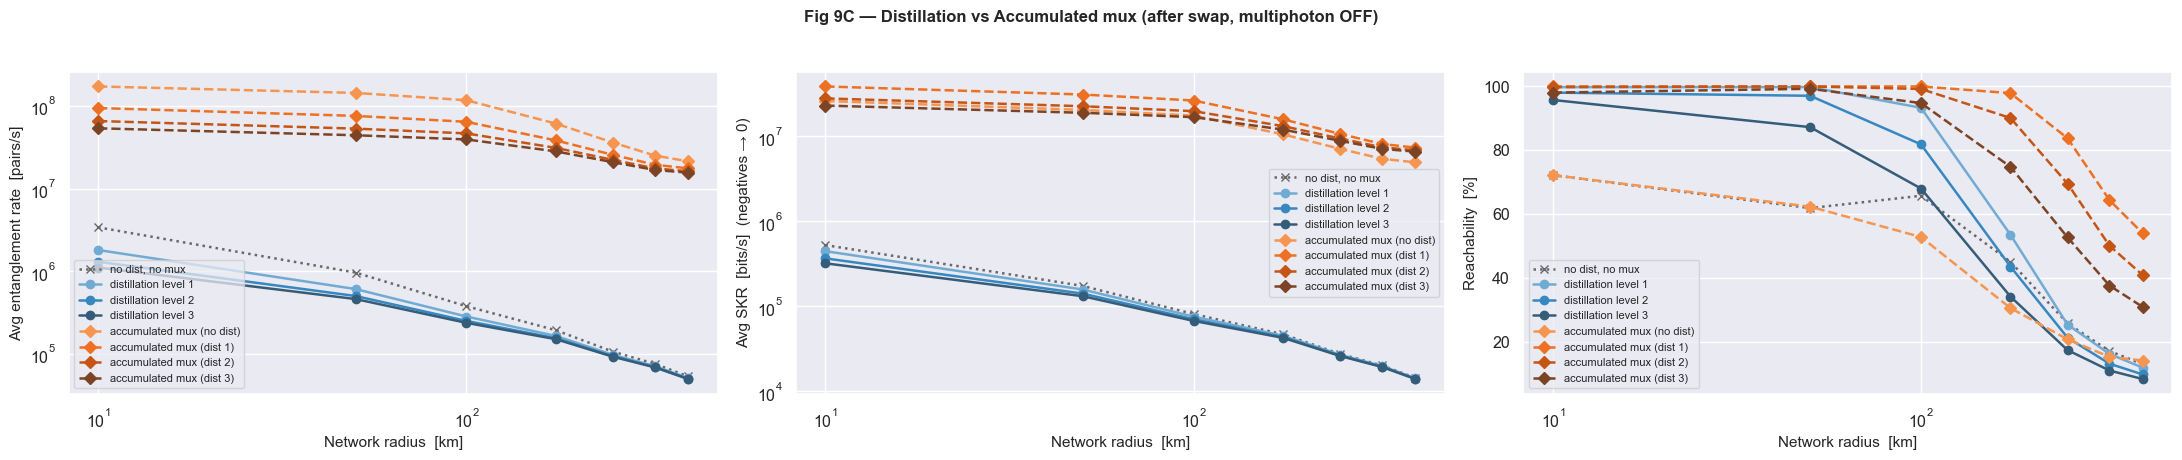

Figure 9C done.


In [25]:
# ── 9C: Dist vs Accumulated mux — after swap ─────────────────────────────────
fig9c, axes9c = make_fig('Fig 9C — Distillation vs Accumulated mux (after swap, multiphoton OFF)')

plot_line(axes9c, RADII,
          radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=False, tag='baseline', multiphoton=True),
          'no dist, no mux', pal4_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes9c, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII, multiphoton=True,
                                  distillation=True, multiplexing_type=None,
                                  distillation_level=lv,
                                  distillation_time='after_swap',
                                  tag=f'dist lv{lv} after'),
              f'distillation level {lv}', pal4_blue[li])

plot_line(axes9c, RADII,
          radius_sweep_shared(SHARED_GRAPHS, RADII,
                              distillation=False, multiplexing_type='accumulated', multiphoton=True,
                              tag='accumulated mux'),
          'accumulated mux (no dist)', pal4_org[0], ls='--', marker='D')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes9c, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type='accumulated', multiphoton=False, distillation_level=lv, distillation_time='after_swap',
                                  tag='accumulated mux'),
              f'accumulated mux (dist {lv})', pal4_org[li+1], ls='--', marker='D')

finish_axes(axes9c, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('plots/fig9C_dist_vs_accumulated_after_swap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9C done.')


  [baseline]  r=10 km …
  [baseline]  r=50 km …
  [baseline]  r=100 km …
  [baseline]  r=175 km …
  [baseline]  r=250 km …
  [baseline]  r=325 km …
  [baseline]  r=400 km …
  [dist-only lv1 after]  r=10 km …
  [dist-only lv1 after]  r=50 km …
  [dist-only lv1 after]  r=100 km …
  [dist-only lv1 after]  r=175 km …
  [dist-only lv1 after]  r=250 km …
  [dist-only lv1 after]  r=325 km …
  [dist-only lv1 after]  r=400 km …
  [dist-only lv2 after]  r=10 km …
  [dist-only lv2 after]  r=50 km …
  [dist-only lv2 after]  r=100 km …
  [dist-only lv2 after]  r=175 km …
  [dist-only lv2 after]  r=250 km …
  [dist-only lv2 after]  r=325 km …
  [dist-only lv2 after]  r=400 km …
  [dist-only lv3 after]  r=10 km …
  [dist-only lv3 after]  r=50 km …
  [dist-only lv3 after]  r=100 km …
  [dist-only lv3 after]  r=175 km …
  [dist-only lv3 after]  r=250 km …
  [dist-only lv3 after]  r=325 km …
  [dist-only lv3 after]  r=400 km …
  [single-burst lv1 after]  r=10 km …
  [single-burst lv1 after]  r=50 km …
 

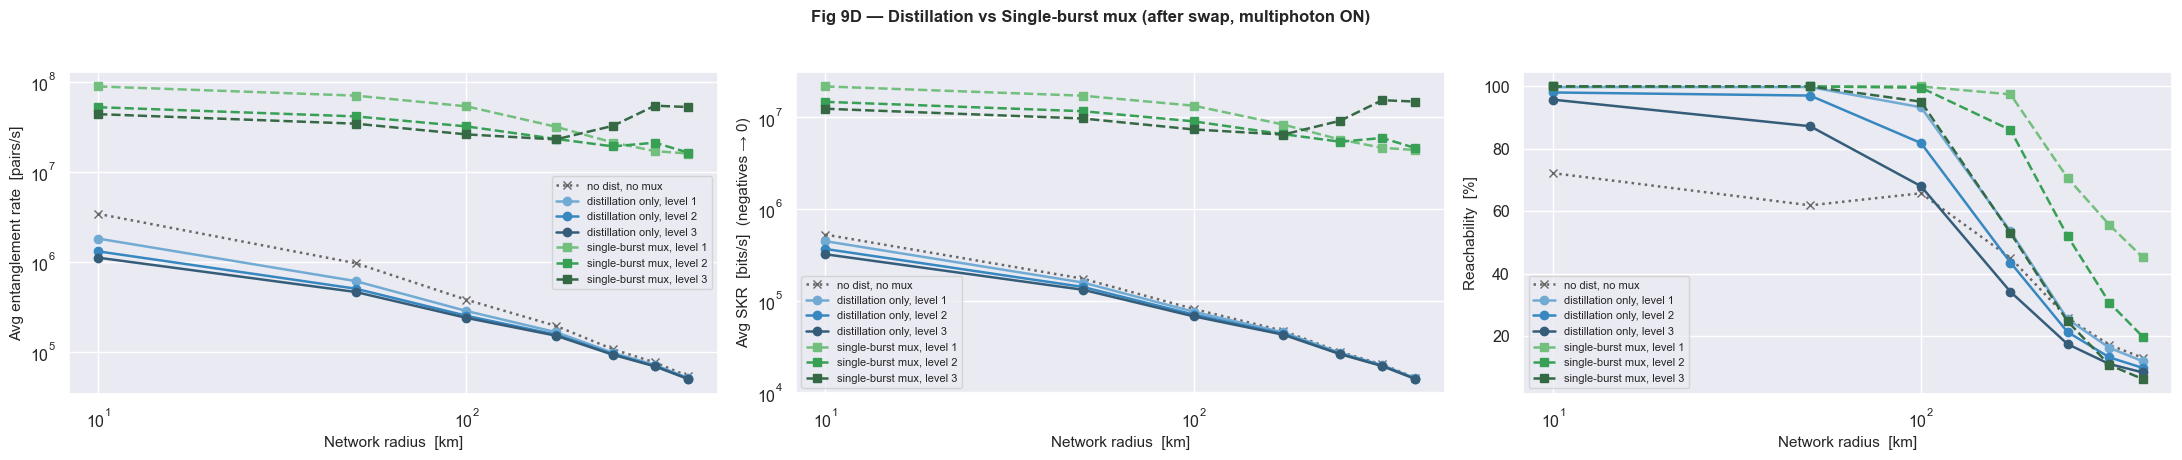

Figure 9D done.


In [24]:
# ── 9D: Dist vs Single-burst mux — after swap ────────────────────────────────
fig9d, axes9d = make_fig('Fig 9D — Distillation vs Single-burst mux (after swap, multiphoton ON)')

plot_line(axes9d, RADII,
          radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=False, tag='baseline', multiphoton=True),
          'no dist, no mux', pal5_grey[0], ls=':', marker='x')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes9d, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type=None, multiphoton=True,
                                  distillation_level=lv,
                                  distillation_time='after_swap',
                                  tag=f'dist-only lv{lv} after'),
              f'distillation only, level {lv}', pal5_blue[li], ls='-', marker='o')

for li, lv in enumerate(DIST_LEVELS):
    plot_line(axes9d, RADII,
              radius_sweep_shared(SHARED_GRAPHS, RADII,
                                  distillation=True, multiplexing_type='single_burst', multiphoton=True,
                                  distillation_level=lv,
                                  distillation_time='after_swap',
                                  tag=f'single-burst lv{lv} after'),
              f'single-burst mux, level {lv}', pal5_green[li], ls='--', marker='s')

finish_axes(axes9d, xlabel='Network radius  [km]')
plt.tight_layout()
plt.savefig('plots/fig9D_dist_vs_singleburst_after_swap_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9D done.')


---
## Figure 8 — Dijkstra path diagnostics: hops & distance vs P\_BSM
Fixed (src, tgt) pair. Vary P\_BSM. Three panels = three radii.
Shaded band = min–max across N\_TRIALS realisations.
**Fairness:** same graph ensemble per radius; only P\_BSM changes.


In [ ]:
shared_graphs_dijk = build_shared_graphs(RADII_DIJKSTRA, n_nodes=400)

In [ ]:
def dijkstra_diag_shared_all_targets(shared_graphs, radius_km, P_BSM_vals,
                                     src=0, just_transmittance=False):
    """Dijkstra diagnostics using shared graph topologies (All reachable nodes)."""
    hm, hmin, hmax, dm, dmin, dmax = [], [], [], [], [], []

    for pb in P_BSM_vals:
        print(f'  r={radius_km} km  P_BSM={pb:.2f} …')
        h_all, d_all = [], []

        for A, dist_mtx, coords in shared_graphs[radius_km]:
            net = QuantumRepeaterNetwork(
                make_params(pb), A, dist_mtx, coords,
                architecture='node', scale=float(radius_km),
                multiphoton=False, distillation=False,
                just_transmittance=just_transmittance, multiplexing_type=None
            )
            try:
                # When target=None, net.optimal_path returns (costs_dict, paths_dict)
                _, paths_dict = net.optimal_path(src, target=None)

                # Iterate through all reachable nodes from the source
                for target_node, path in paths_dict.items():
                    # Skip the trivial 0-hop path from the source to itself
                    if target_node == src:
                        continue

                    h_all.append(len(path) - 1)
                    d_all.append(sum(net.path_distances(path)))

            except Exception as e:
                # Catch any routing errors for this specific graph instance
                pass

        # Handle case where no paths exist (e.g., disconnected graph)
        if not h_all:
            h_all.append(np.nan)
            d_all.append(np.nan)

        h, d = np.array(h_all, float), np.array(d_all, float)
        hm.append(np.nanmean(h));  hmin.append(np.nanmin(h));  hmax.append(np.nanmax(h))
        dm.append(np.nanmean(d));  dmin.append(np.nanmin(d));  dmax.append(np.nanmax(d))

    return (np.array(hm), np.array(hmin), np.array(hmax),
            np.array(dm), np.array(dmin), np.array(dmax))


n_panels = len(RADII_DIJKSTRA)
fig8, axes8 = plt.subplots(2, n_panels, figsize=(6 * n_panels, 8))
fig8.suptitle(
    f'Fig 8 — Dijkstra diagnostics: hops & distance vs P_BSM\n'
    f'(src={SOURCE_NODE} , just_transmittance=False, no dist, multiphoton OFF)',
    fontsize=12, fontweight='bold'
)

pal8 = sns.color_palette('tab10', n_panels)

for ci, r in enumerate(RADII_DIJKSTRA):
    hm, hmin, hmax, dm, dmin, dmax = dijkstra_diag_shared_all_targets(shared_graphs_dijk, r, P_BSM_VALUES, just_transmittance=False)
    c = pal8[ci]

    for row_ax, (mean_v, lo, hi, ylabel) in zip(
        axes8[:, ci],
        [(hm, hmin, hmax, 'Hop count'),
         (dm, dmin, dmax, 'Total path distance  [km]')]
    ):
        row_ax.plot(P_BSM_VALUES, mean_v, color=c, lw=2, marker='o', label='mean')
        #row_ax.fill_between(P_BSM_VALUES, lo, hi, color=c, alpha=0.25, label='min–max')
        row_ax.set_title(f'radius = {r} km', fontsize=11)
        row_ax.set_xlabel('P_BSM')
        #row_ax.set_ylim(130, 160)
        row_ax.set_ylabel(ylabel)
        row_ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/fig8_dijkstra_diagnostics_trans.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 done.')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Assuming you have your classes imported:
# from sequential_repeaters_dist import RepeaterParams, QuantumRepeaterNetwork, S2_graph_definite_N

# 1. Setup your friend's exact parameters
N = 400
n_iter = 10
beta = 2.6261
mu = 0.0233

# Sweep P_BSM from 0.01 to 0.5
p_Bells = np.linspace(0.01, 0.5, 10)

# Calculate the single fixed radius (~56.4 km) based on your friend's density
rhos = 0.01
radius = np.sqrt(N / (4 * np.pi * rhos))

# Dictionaries to accumulate statistics across the 10 iterations
all_avg_probs = {pb: [] for pb in p_Bells}
all_avg_hops = {pb: [] for pb in p_Bells}

alice = 0

for instance in range(n_iter):
    print(f"Running graph iteration {instance+1}/{n_iter}...")

    # Generate ONE random topology per iteration
    A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)

    # Scale relative distances to physical km
    dist_mtx = Dists * radius

    for p_bsm in p_Bells:
        # Create parameters and set the current P_BSM for this step
        params = RepeaterParams()  # Use your custom parameter generator if you have one
        params.P_BSM = p_bsm

        # Instantiate YOUR robust network object
        net = QuantumRepeaterNetwork(
            params, A, dist_mtx, coords,
            architecture='node', scale=float(radius),
            multiphoton=False, distillation=False
        )

        # Run Dijkstra to ALL nodes at once
        try:
            costs_dict, paths_dict = net.optimal_path(source=alice, target=None)
        except Exception:
            continue  # Failsafe if graph is completely disconnected

        instance_probs = []
        instance_hops = []

        # Extract and clean the data
        for target_node, path in paths_dict.items():
            if target_node == alice:
                continue  # FIX 1: Skip the Alice-to-Alice ghost path!

            # Calculate hop count
            hops = len(path) - 1

            # FIX 2: Convert your log2 cost back to probability
            # (We divide by p_bsm to refund the 1 extra penalty applied to the edges)
            prob = (2 ** -costs_dict[target_node]) / p_bsm

            instance_hops.append(hops)
            instance_probs.append(prob)

        # Store the average for this specific graph instance
        if instance_probs:
            all_avg_probs[p_bsm].append(np.mean(instance_probs))
            all_avg_hops[p_bsm].append(np.mean(instance_hops))

# --- PLOTTING ---

# Calculate final means across all 10 iterations
final_probs = [np.mean(all_avg_probs[pb]) for pb in p_Bells]
final_hops = [np.mean(all_avg_hops[pb]) for pb in p_Bells]

# Figure 1: Rate vs P_BSM
plt.figure(figsize=(8, 5))
plt.plot(p_Bells, final_probs, marker='o', color='blue', linewidth=2)
plt.yscale('log')
plt.ylabel('Average End-to-End Entanglement Rate')
plt.xlabel('BSM Success Probability ($P_{BSM}$)')
plt.title(f'Network Rate vs $P_{{{BSM}}}$ (N={N}, R={radius:.1f} km)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Figure 2: Hops vs P_BSM
plt.figure(figsize=(8, 5))
plt.plot(p_Bells, final_hops, marker='s', color='red', linewidth=2)
plt.ylabel('Average Shortest Path Length (Hops)')
plt.xlabel('BSM Success Probability ($P_{BSM}$)')
plt.title(f'Optimal Routing Hops vs $P_{{{BSM}}}$')
plt.grid(True, ls="--", alpha=0.7)
plt.show()

---
## Figure 10 — Bonus exploratory plots

Eight simple, targeted plots designed to support write-up and conclusions.
Each has a brief justification explaining what insight it adds.

| Sub-fig | Type | X-axis | What it reveals |
|---------|------|--------|-----------------|
| 10a | Line plot | Radius | SKR gain ratio: mux / no-mux — directly quantifies when mux helps |
| 10b | Line plot | Radius | Reachability difference: before − after swap — shows timing sensitivity |
| 10c | Histogram | — | Distribution of per-node reachability across all nodes, one radius per panel |
| 10d | Line plot | Distillation level | Coherence penalty factor per level (T ratio) — explains why more distillation often hurts |
| 10e | Scatter | Radius | Rate vs reachability coloured by config — Pareto frontier of the configuration space |
| 10f | Line plot | P\_BSM | SKR sensitivity (dSKR/dP\_BSM) — finds operating point where improving P\_BSM matters most |
| 10g | Line plot | Radius | Relative benefit of after-swap vs before-swap distillation for each mux mode |
| 10h | Bar chart | Config | Avg rate and reachability at a single representative radius — quick config comparison |


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10a — SKR gain ratio: accumulated mux / no-mux (before swap, level=1)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: A ratio plot removes the absolute scale and directly shows the
#      multiplicative benefit of multiplexing as a function of radius.
#      Values > 1 mean mux helps; crossing 1 shows the break-even distance.

data_base_a = radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=False, tag='base10a')
data_mux_a  = radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=False,
                                   multiplexing_type='accumulated', tag='mux10a')

fig10a, ax10a = plt.subplots(figsize=(8, 5))
ratio = np.array(data_mux_a['avg_rate']) / (np.array(data_base_a['avg_rate']) + 1e-20)
ax10a.plot(RADII, ratio, marker='o', lw=2, color='steelblue')
ax10a.axhline(1.0, color='grey', ls='--', lw=1.2, label='ratio = 1  (no gain)')
ax10a.set_xlabel('Network radius  [km]', fontsize=12)
ax10a.set_ylabel('Avg rate ratio  (accumulated mux / baseline)', fontsize=12)
ax10a.set_title('Fig 10a — Multiplexing gain ratio vs radius', fontsize=12, fontweight='bold')
ax10a.set_xscale('log')
ax10a.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10a_mux_gain_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10a done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10b — Reachability difference: before_swap − after_swap (level=1, mux=None)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: A plain difference plot isolates the timing effect on connectivity
#      (independent of raw rate), making it easy to write about which regime
#      benefits from distilling before vs after the swap.

data_before_b = radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=True,
                                     multiplexing_type=None, distillation_level=1,
                                     distillation_time='before_swap', tag='before10b')
data_after_b  = radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=True,
                                     multiplexing_type=None, distillation_level=1,
                                     distillation_time='after_swap', tag='after10b')

diff_reach = np.array(data_before_b['reachability']) - np.array(data_after_b['reachability'])
diff_rate  = np.array(data_before_b['avg_rate'])     - np.array(data_after_b['avg_rate'])

fig10b, axes10b = plt.subplots(1, 2, figsize=(13, 5))
fig10b.suptitle('Fig 10b — Before-swap minus after-swap (level=1, mux=None)',
                fontsize=12, fontweight='bold')

for ax, diff, ylabel in zip(axes10b,
                             [diff_reach, diff_rate],
                             ['Δ Reachability  [pp]', 'Δ Avg rate  [pairs/s]']):
    ax.plot(RADII, diff, marker='o', lw=2, color='darkorange')
    ax.axhline(0, color='grey', ls='--', lw=1.2)
    ax.set_xlabel('Network radius  [km]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xscale('log')

sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10b_before_minus_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10b done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10c — Histogram: per-node reachability distribution at selected radii
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The scalar avg_reachability hides whether the network is uniformly
#      connected or has a few super-hubs serving most pairs.  A histogram
#      shows the spread — crucial for writing about network fairness.

RADII_HIST = [10, 100, 325]
fig10c, axes10c = plt.subplots(1, len(RADII_HIST), figsize=(14, 5), sharey=True)
fig10c.suptitle('Fig 10c — Per-node reachability distribution  (no dist, no mux)',
                fontsize=12, fontweight='bold')

for ax, r in zip(axes10c, RADII_HIST):
    A, dist, coords = SHARED_GRAPHS[r][0]   # use first trial
    net_c = QuantumRepeaterNetwork(
        make_params(), A, dist, coords,
        architecture='node', scale=float(r),
        multiphoton=False, distillation=False,
    )
    node_reach = []
    for src in range(N_NODES):
        try:
            df = net_c.analyze_all_paths(src)
            n_reach = (df['SKR'] > 0).sum()
        except Exception:
            n_reach = 0
        node_reach.append(n_reach / max(N_NODES - 1, 1) * 100)
    ax.hist(node_reach, bins=20, color='mediumpurple', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Node reachability  [%]', fontsize=11)
    ax.set_title(f'r = {r} km', fontsize=11)
    ax.set_ylabel('Number of nodes' if ax is axes10c[0] else '', fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10c_node_reachability_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10c done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10d — Coherence penalty: T ratio vs distillation level (r=100 km)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Directly answers the "why does higher distillation level give worse
#      results?" question.  Plotting T(level) / T(level=0) shows the
#      multiplicative time cost that coherence decay must overcome.

from sequential_repeaters_dist import BBPSSW

def estimate_T_ratio(radius_km, distillation_level, distillation_time='before_swap',
                     A=None, dist=None, coords=None):
    """Estimate mean waiting-time ratio T(level) / T(level=1) over SHARED_GRAPHS."""
    p = make_params()
    ratios = []
    graphs_to_use = SHARED_GRAPHS[radius_km] if A is None else [(A, dist, coords)]
    for Ai, di, ci in graphs_to_use:
        net = QuantumRepeaterNetwork(
            p, Ai, di, ci, architecture='node', scale=float(radius_km),
            multiphoton=False, distillation=True, distillation_level=distillation_level,
            distillation_time=distillation_time,
        )
        net_base = QuantumRepeaterNetwork(
            p, Ai, di, ci, architecture='node', scale=float(radius_km),
            multiphoton=False, distillation=True, distillation_level=1,
            distillation_time=distillation_time,
        )
        m = net.network_metrics(verbose=False)
        m0 = net_base.network_metrics(verbose=False)
        r0 = m0['avg_rate']
        r_lv = m['avg_rate']
        if r0 > 0 and r_lv > 0:
            # T ∝ 1/rate
            ratios.append(r0 / r_lv)
    return np.mean(ratios) if ratios else np.nan

RADIUS_COH = 100
T_ratios_before = [estimate_T_ratio(RADIUS_COH, lv, 'before_swap') for lv in LEVELS]
T_ratios_after  = [estimate_T_ratio(RADIUS_COH, lv, 'after_swap')  for lv in LEVELS]

fig10d, ax10d = plt.subplots(figsize=(7, 5))
ax10d.plot(LEVELS, T_ratios_before, marker='o', lw=2, color='royalblue',  label='before swap')
ax10d.plot(LEVELS, T_ratios_after,  marker='s', lw=2, color='tomato',     label='after swap',  ls='--')
ax10d.axhline(1.0, color='grey', ls=':', lw=1)
ax10d.set_xlabel('Distillation level', fontsize=12)
ax10d.set_ylabel('T(level) / T(level=1)  [waiting-time ratio]', fontsize=12)
ax10d.set_title(f'Fig 10d — Coherence-penalty factor vs distillation level  (r={RADIUS_COH} km)',
                fontsize=12, fontweight='bold')
ax10d.set_xticks(LEVELS)
ax10d.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10d_coherence_penalty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10d done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10e — Scatter: avg rate vs reachability, coloured by config
# ─────────────────────────────────────────────────────────────────────────────
# WHY: A rate-vs-reachability scatter collapses all configurations onto a
#      2-D plane, making the Pareto frontier immediately visible.  Points on
#      the upper-right are both fast and well-connected.

configs_e = [
    ('baseline',          dict(distillation=False)),
    ('dist lv1 before',   dict(distillation=True, distillation_level=1, distillation_time='before_swap')),
    ('dist lv2 before',   dict(distillation=True, distillation_level=2, distillation_time='before_swap')),
    ('dist lv1 after',    dict(distillation=True, distillation_level=1, distillation_time='after_swap')),
    ('acc mux',           dict(distillation=False, multiplexing_type='accumulated')),
    ('acc+dist lv1 bef',  dict(distillation=True, multiplexing_type='accumulated',
                                distillation_level=1, distillation_time='before_swap')),
    ('burst+dist lv1 bef',dict(distillation=True, multiplexing_type='single_burst',
                                distillation_level=1, distillation_time='before_swap')),
]

pal_e = sns.color_palette('tab10', len(configs_e))
fig10e, ax10e = plt.subplots(figsize=(9, 6))

for (lbl, kw), col in zip(configs_e, pal_e):
    rates, reaches = [], []
    for r in RADII:
        d = radius_sweep_shared(SHARED_GRAPHS, [r], **kw)
        rates.append(d['avg_rate'][0])
        reaches.append(d['reachability'][0])
    ax10e.scatter(reaches, rates, color=col, label=lbl, s=60, zorder=4)
    ax10e.plot(reaches, rates, color=col, alpha=0.35, lw=1)

ax10e.set_xlabel('Reachability  [%]', fontsize=12)
ax10e.set_ylabel('Avg rate  [pairs/s]', fontsize=12)
ax10e.set_yscale('log')
ax10e.set_title('Fig 10e — Rate vs reachability across radii  (each point = one radius)',
                fontsize=12, fontweight='bold')
ax10e.legend(fontsize=8, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10e_rate_vs_reachability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10e done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10f — SKR sensitivity to P_BSM  (dSKR/dP_BSM via finite difference)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Absolute SKR vs P_BSM is already in Fig 6.  The derivative tells you
#      *where* on the P_BSM axis hardware improvements matter most — useful
#      for writing about engineering priorities.

data_f = pbsm_sweep_shared(SHARED_GRAPHS, P_BSM_VALUES, RADIUS_LARGE,
                            distillation=True, multiplexing_type=None,
                            distillation_level=1, distillation_time='before_swap',
                            tag='sensitivity10f')

rates_f = np.array(data_f['avg_rate'])
grad = np.gradient(rates_f, P_BSM_VALUES)

fig10f, axes10f = plt.subplots(1, 2, figsize=(13, 5))
fig10f.suptitle(f'Fig 10f — P_BSM sensitivity  (r={RADIUS_LARGE} km, dist lv1 before)',
                fontsize=12, fontweight='bold')

axes10f[0].plot(P_BSM_VALUES, rates_f, marker='o', lw=2, color='steelblue')
axes10f[0].set_yscale('log')
axes10f[0].set_xlabel('P_BSM', fontsize=12)
axes10f[0].set_ylabel('Avg rate  [pairs/s]', fontsize=12)
axes10f[0].set_title('Avg rate vs P_BSM', fontsize=11)

axes10f[1].plot(P_BSM_VALUES, np.abs(grad), marker='o', lw=2, color='tomato')
axes10f[1].set_xlabel('P_BSM', fontsize=12)
axes10f[1].set_ylabel('|d(Avg rate)/d(P_BSM)|', fontsize=12)
axes10f[1].set_title('Rate sensitivity (finite-difference gradient)', fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10f_pbsm_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10f done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10g — Relative benefit of after-swap vs before-swap per mux mode
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Fig 3 shows before/after as two lines.  This plot shows their *ratio*
#      broken down by mux mode, so the interaction between timing and
#      multiplexing strategy is immediately readable.

fig10g, axes10g = plt.subplots(1, 3, figsize=(16, 5))
fig10g.suptitle('Fig 10g — After/before-swap rate ratio per mux mode  (dist level=1)',
                fontsize=12, fontweight='bold')
pal_g = sns.color_palette('Set2', len(MUX_MODES))

for ax, key, ylabel in zip(axes10g, METRIC_KEYS, [METRIC_LABELS[k] for k in METRIC_KEYS]):
    for (mux, col) in zip(MUX_MODES, pal_g):
        lbl = mux_lbl[mux]
        d_bef = radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=True,
                                     multiplexing_type=mux, distillation_level=1,
                                     distillation_time='before_swap', tag=f'{lbl} bef g')
        d_aft = radius_sweep_shared(SHARED_GRAPHS, RADII, distillation=True,
                                     multiplexing_type=mux, distillation_level=1,
                                     distillation_time='after_swap', tag=f'{lbl} aft g')
        ratio_g = np.array(d_aft[key]) / (np.array(d_bef[key]) + 1e-30)
        ax.plot(RADII, ratio_g, marker='o', lw=2, color=col, label=lbl)
    ax.axhline(1.0, color='grey', ls='--', lw=1.2)
    ax.set_xscale('log')
    ax.set_xlabel('Network radius  [km]', fontsize=11)
    ax.set_ylabel(f'after / before  ({ylabel.split("[")[0].strip()})', fontsize=10)
    ax.legend(fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10g_after_vs_before_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10g done.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 10h — Bar chart: configuration comparison at a representative radius
# ─────────────────────────────────────────────────────────────────────────────
# WHY: Line plots across many radii are great for trends but make it hard to
#      rank configurations at a specific operating point.  A bar chart at one
#      representative radius (100 km) gives an at-a-glance ranking that is
#      easy to cite in write-up conclusions.

RADIUS_BAR = 100

configs_h = [
    ('baseline',                dict(distillation=False)),
    ('dist lv1\nbefore',       dict(distillation=True, distillation_level=1, distillation_time='before_swap')),
    ('dist lv2\nbefore',       dict(distillation=True, distillation_level=2, distillation_time='before_swap')),
    ('dist lv3\nbefore',       dict(distillation=True, distillation_level=3, distillation_time='before_swap')),
    ('dist lv1\nafter',        dict(distillation=True, distillation_level=1, distillation_time='after_swap')),
    ('acc mux',                  dict(distillation=False, multiplexing_type='accumulated')),
    ('acc+dist lv1\nbefore',   dict(distillation=True, multiplexing_type='accumulated',
                                     distillation_level=1, distillation_time='before_swap')),
    ('burst+dist lv1\nbefore', dict(distillation=True, multiplexing_type='single_burst',
                                     distillation_level=1, distillation_time='before_swap')),
    ('burst+dist lv1\nafter',  dict(distillation=True, multiplexing_type='single_burst',
                                     distillation_level=1, distillation_time='after_swap')),
]

labels_h = [c[0] for c in configs_h]
rates_h, reaches_h = [], []

for lbl, kw in configs_h:
    d = radius_sweep_shared(SHARED_GRAPHS, [RADIUS_BAR], **kw)
    rates_h.append(d['avg_rate'][0])
    reaches_h.append(d['reachability'][0])

x = np.arange(len(labels_h))
width = 0.38

fig10h, axes10h = plt.subplots(1, 2, figsize=(16, 6))
fig10h.suptitle(f'Fig 10h — Configuration comparison at r={RADIUS_BAR} km',
                fontsize=12, fontweight='bold')

axes10h[0].bar(x, rates_h, width, color=sns.color_palette('Blues_d', len(labels_h)))
axes10h[0].set_yscale('log')
axes10h[0].set_ylabel('Avg rate  [pairs/s]', fontsize=12)
axes10h[0].set_title('Avg entanglement generation rate', fontsize=11)
axes10h[0].set_xticks(x); axes10h[0].set_xticklabels(labels_h, fontsize=8, rotation=30, ha='right')

axes10h[1].bar(x, reaches_h, width, color=sns.color_palette('Greens_d', len(labels_h)))
axes10h[1].set_ylabel('Reachability  [%]', fontsize=12)
axes10h[1].set_title('Reachability', fontsize=11)
axes10h[1].set_xticks(x); axes10h[1].set_xticklabels(labels_h, fontsize=8, rotation=30, ha='right')

sns.despine()
plt.tight_layout()
plt.savefig('plots/fig10h_config_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10h done.')
